# Tóm tắt kết quả Dehazing và Detection

Notebook này gọi các hàm đã thiết lập để trực quan hóa kết quả: so sánh ảnh Ground Truth (nếu có), ảnh Hazy và các ảnh đã khôi phục bằng các cấu hình DCP khác nhau. Đồng thời, hiển thị bounding box của YOLOv26 trên các ảnh này.

In [37]:
import os
import cv2
import matplotlib.pyplot as plt
import pandas as pd
import yaml
import sys
sys.path.append('A:/HUST_on_GitHub/ProjectCV')

from ultralytics import YOLO
from src.restoration.dcp import DCPDehazeFilter, DCPConfig
from src.metrics.full_reference import compute_ssim, compute_psnr
from src.metrics.no_reference import compute_brisque

## 1. Tải các cấu hình và mô hình YOLO

In [38]:
import dataclasses

def load_cfg(path):
    with open(path, 'r') as f:
        cfg = yaml.safe_load(f)
    if not cfg:
        return {}
    
    # Chỉ giữ lại các keys có trong DCPConfig
    valid_keys = {field.name for field in dataclasses.fields(DCPConfig)}
    return {k: v for k, v in cfg.items() if k in valid_keys}

configs = {
    "Default": DCPConfig(**load_cfg('A:/HUST_on_GitHub/ProjectCV/configs/dcp_default.yaml')),
    "Optuna_1": DCPConfig(**load_cfg('A:/HUST_on_GitHub/ProjectCV/results/optuna/config1_reside_ssim/best_config.yaml')) if os.path.exists('A:/HUST_on_GitHub/ProjectCV/results/optuna/config1_reside_ssim/best_config.yaml') else None,
    "Optuna_2": DCPConfig(**load_cfg('A:/HUST_on_GitHub/ProjectCV/results/optuna/config2_dawn_brisque/best_config.yaml')) if os.path.exists('A:/HUST_on_GitHub/ProjectCV/results/optuna/config2_dawn_brisque/best_config.yaml') else None,
    "Optuna_3": DCPConfig(**load_cfg('A:/HUST_on_GitHub/ProjectCV/results/optuna/config3_dawn_map50/best_config.yaml')) if os.path.exists('A:/HUST_on_GitHub/ProjectCV/results/optuna/config3_dawn_map50/best_config.yaml') else None
}

filters = {k: DCPDehazeFilter(v) for k, v in configs.items() if v is not None}

yolo_model = YOLO('A:/HUST_on_GitHub/ProjectCV/yolo26n.pt')

## 2. Bảng kết quả Metrics (Final Evaluation)

In [39]:
eval_csv = 'A:/HUST_on_GitHub/ProjectCV/results/final_evaluation.csv'
if os.path.exists(eval_csv):
    df = pd.read_csv(eval_csv)
    display(df)
else:
    print("Chưa có file kết quả, hãy chạy 07_eval_all_configs.py")

,Config,RESIDE_SSIM,RESIDE_PSNR,DAWN_BRISQUE,DAWN_mAP50
0,Default,0.844979,17.871949,41.244965,0.070866
1,Optuna_SSIM,0.887498,21.138578,42.334685,0.083906
2,Optuna_BRISQUE,0.797014,18.466070,38.985946,0.072198
3,Optuna_mAP50,0.879881,20.378004,41.775031,0.087002


## 3. Trực quan hóa kết quả (RESIDE)
So sánh Hazy vs Ground Truth vs Default vs Config 1

In [40]:
reside_hazy_path = 'A:/HUST_on_GitHub/ProjectCV/dataset/RESIDE-6K/test/hazy/0001.png'
reside_gt_path = 'A:/HUST_on_GitHub/ProjectCV/dataset/RESIDE-6K/test/clear/0001.png'

if os.path.exists(reside_hazy_path) and os.path.exists(reside_gt_path):
    hazy_img = cv2.imread(reside_hazy_path)
    gt_img = cv2.imread(reside_gt_path)
    
    imgs_reside = [hazy_img, gt_img]
    titles_reside = ["1. Hazy", "2. Ground Truth"]
    
    for cfg_name in ["Default", "Optuna_1", "Optuna_2", "Optuna_3"]:
        if cfg_name in configs and configs[cfg_name] is not None:
            dehazer = DCPDehazeFilter(configs[cfg_name])
            res = dehazer.restore(hazy_img)
            imgs_reside.append(res)
            titles_reside.append(f"{cfg_name}")
    show_images_yolo(imgs_reside, titles_reside, figsize=(25, 5))
else:
    print("Not found")


Not found


## 4. Trực quan hóa Detection (DAWN)
Sử dụng YOLOv26 để dự đoán trên ảnh Hazy và ảnh sau khi Dehaze.

In [41]:
import cv2
import matplotlib.pyplot as plt
import os
from src.restoration.dcp import DCPDehazeFilter

# Draw Ground Truth BB
def draw_gt_boxes(img, label_path):
    img_copy = img.copy()
    if not os.path.exists(label_path):
        return img_copy
        
    CLASS_NAMES = {
        1: "person",
        2: "bicycle",
        3: "car",
        4: "motorcycle",
        6: "bus",
        8: "truck"
    }
    
    h, w = img_copy.shape[:2]
    with open(label_path, 'r') as f:
        lines = f.readlines()
        
    for line in lines:
        parts = line.strip().split()
        if len(parts) >= 5:
            cls_id = int(parts[0])
            cls_name = CLASS_NAMES.get(cls_id, str(cls_id))
            
            x_center = float(parts[1]) * w
            y_center = float(parts[2]) * h
            box_w = float(parts[3]) * w
            box_h = float(parts[4]) * h
            
            x1 = int(x_center - box_w / 2)
            y1 = int(y_center - box_h / 2)
            x2 = int(x_center + box_w / 2)
            y2 = int(y_center + box_h / 2)
            
            cv2.rectangle(img_copy, (x1, y1), (x2, y2), (0, 255, 0), 3)
            cv2.putText(img_copy, f"GT: {cls_name}", (x1, max(y1 - 5, 0)), 
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
            
    return img_copy


def show_images_yolo(imgs, titles, figsize=(25, 5)):
    fig, axes = plt.subplots(1, len(imgs), figsize=figsize)
    if len(imgs) == 1: axes = [axes]
    for ax, img, title in zip(axes, imgs, titles):
        ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        ax.set_title(title, fontsize=14, pad=10)
        ax.axis('off')
    plt.tight_layout()
    plt.show()


--- RESTORATION ---


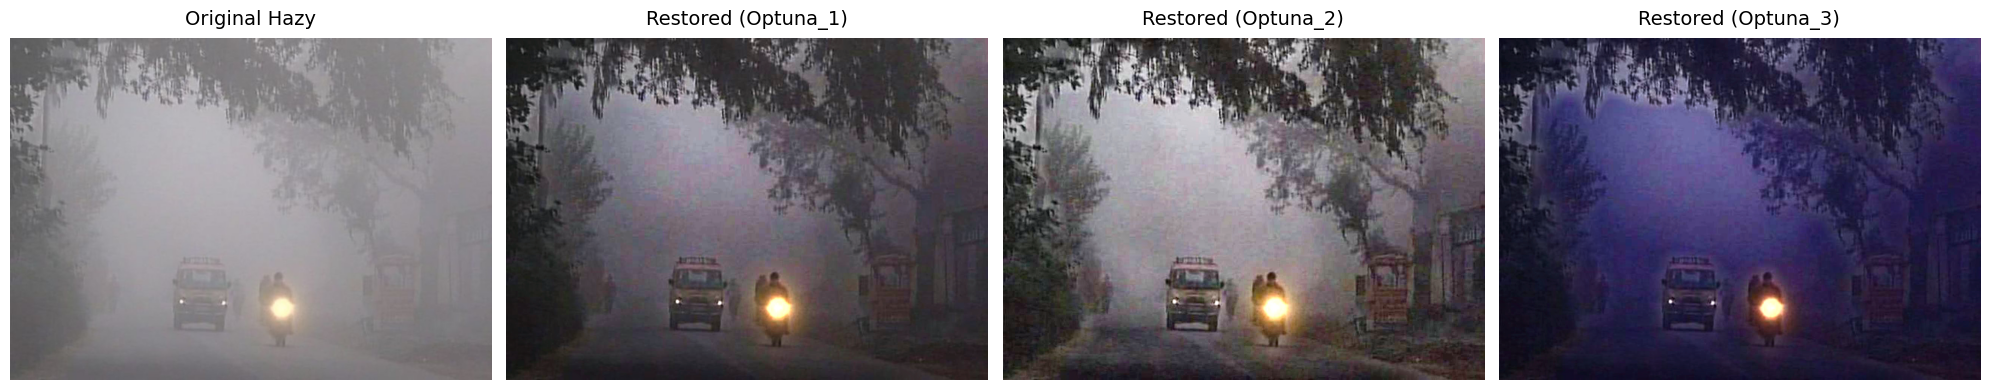


--- DETECTION ---


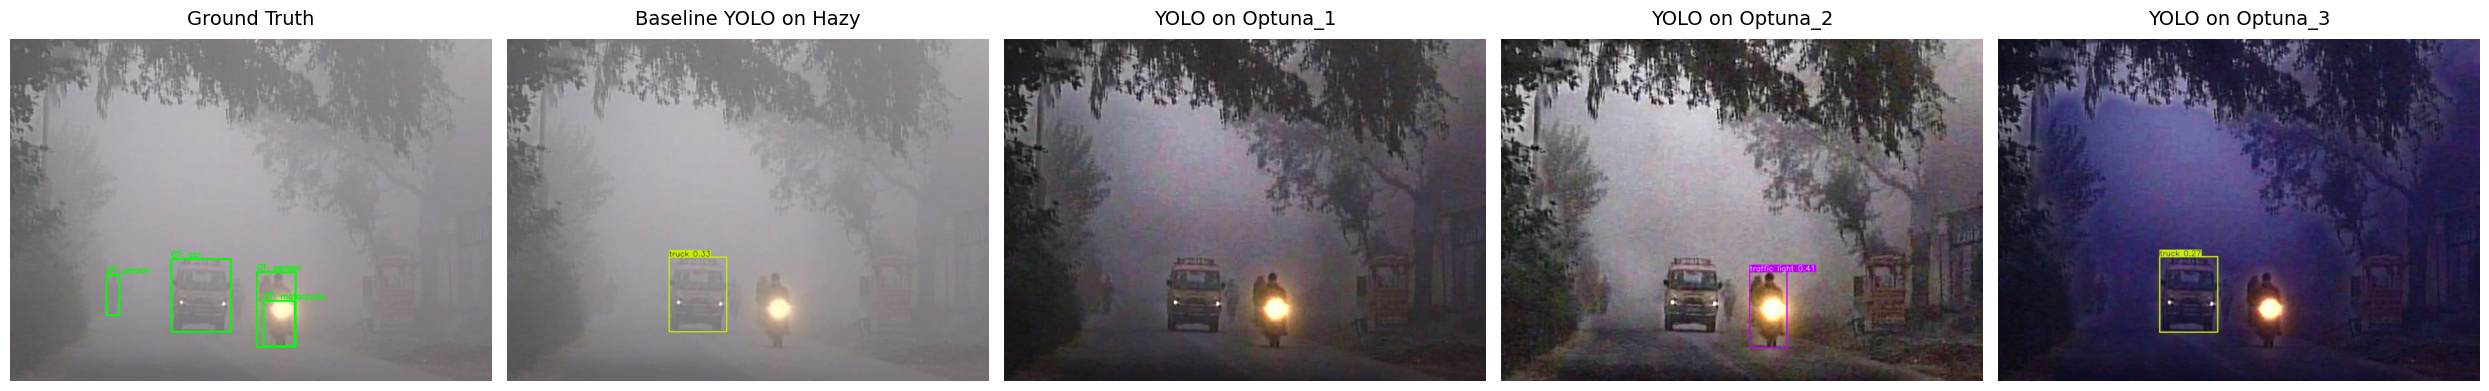

In [42]:
# 2. TRỰC QUAN HÓA TRÊN DAWN (Khôi phục & Detect)
dawn_img_path = 'A:/HUST_on_GitHub/ProjectCV/dataset/DAWN/Fog/foggy-002.jpg'
dawn_lbl_path = 'A:/HUST_on_GitHub/ProjectCV/data/dawn/labels/foggy-002.txt' 

if os.path.exists(dawn_img_path):
    dawn_img = cv2.imread(dawn_img_path)
    
    # --- PHẦN 1: SO SÁNH ẢNH KHÔI PHỤC ---
    print("--- RESTORATION ---")
    imgs_dawn_restored = [dawn_img.copy()]
    titles_dawn_restored = ["Original Hazy"]
    dehazed_dict = {}
    
    for cfg_name in ["Optuna_1", "Optuna_2", "Optuna_3"]:
        if cfg_name in configs and configs[cfg_name] is not None:
            dehazer = DCPDehazeFilter(configs[cfg_name])
            res = dehazer.restore(dawn_img)
            imgs_dawn_restored.append(res)
            titles_dawn_restored.append(f"Restored ({cfg_name})")
            dehazed_dict[cfg_name] = res
            
    show_images_yolo(imgs_dawn_restored, titles_dawn_restored, figsize=(20, 5))
    
    # --- PHẦN 2: SO SÁNH NHẬN DIỆN VẬT THỂ (DETECTION) ---
    print("\n--- DETECTION ---")
    imgs_dawn_det = []
    titles_dawn_det = []
    
    # 1. Ground Truth (Vẽ BB xanh lá lên ảnh gốc)
    gt_plotted = draw_gt_boxes(dawn_img, dawn_lbl_path)
    imgs_dawn_det.append(gt_plotted)
    titles_dawn_det.append("Ground Truth")
    
    # 2. Baseline (YOLO dự đoán trực tiếp trên Hazy)
    res_baseline = yolo_model.predict(dawn_img, verbose=False)[0]
    imgs_dawn_det.append(res_baseline.plot(line_width=2))
    titles_dawn_det.append("Baseline YOLO on Hazy")
    
    # 3. Kết quả YOLO trên các cấu hình đã dehaze
    for cfg_name in ["Optuna_1", "Optuna_2", "Optuna_3"]:
        if cfg_name in dehazed_dict:
            res_det = yolo_model.predict(dehazed_dict[cfg_name], verbose=False)[0]
            imgs_dawn_det.append(res_det.plot(line_width=2))
            titles_dawn_det.append(f"YOLO on {cfg_name}")
            
    show_images_yolo(imgs_dawn_det, titles_dawn_det, figsize=(25, 5))
else:
    print("Không tìm thấy ảnh của tập DAWN, hãy kiểm tra lại đường dẫn!")
